# Task 3: Car Price Prediction with Machine Learning

Predict a used car's selling price based on features like present (showroom) price, age, mileage, fuel type, transmission, and ownership history.

## 1. Load Libraries and Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('car_data.csv')
df.head()

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type Transmission  Owner
0     ritz  2014           3.35           5.59       27000    Petrol       Dealer       Manual      0
1      sx4  2013           4.75           9.54       43000    Diesel       Dealer       Manual      0
2     ciaz  2017           7.25           9.85        6900    Petrol       Dealer       Manual      0
3  wagon r  2011           2.85           4.15        5200    Petrol       Dealer       Manual      0
4    swift  2014           4.60           6.87       42450    Diesel       Dealer       Manual      0


In [ ]:
df.shape

(301, 9)


The dataset has **301 rows** and **9 columns**. No missing values. It contains used-car listings with both the original showroom price (`Present_Price`) and the actual `Selling_Price`, along with mileage, fuel type, transmission, ownership, and registration year (2003-2018).

In [ ]:
df.describe()

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


## 2. Exploratory Data Analysis (EDA)

In [ ]:
print("Fuel types:", df['Fuel_Type'].unique())
print("Selling types:", df['Selling_type'].unique())
print("Transmission:", df['Transmission'].unique())
print("Owner counts:", df['Owner'].unique())

Fuel types: ['Petrol' 'Diesel' 'CNG']
Selling types: ['Dealer' 'Individual']
Transmission: ['Manual' 'Automatic']
Owner counts: [0 1 3]


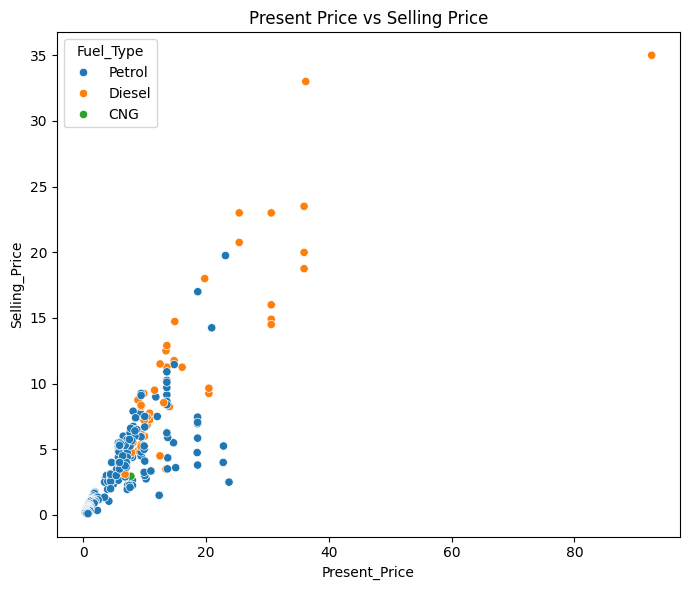

In [ ]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type')
plt.title('Present Price vs Selling Price')
plt.tight_layout()
plt.show()

There's a strong positive relationship between a car's original showroom price (`Present_Price`) and its resale `Selling_Price` — as expected, more expensive new cars retain more value in absolute terms.

## 3. Feature Engineering

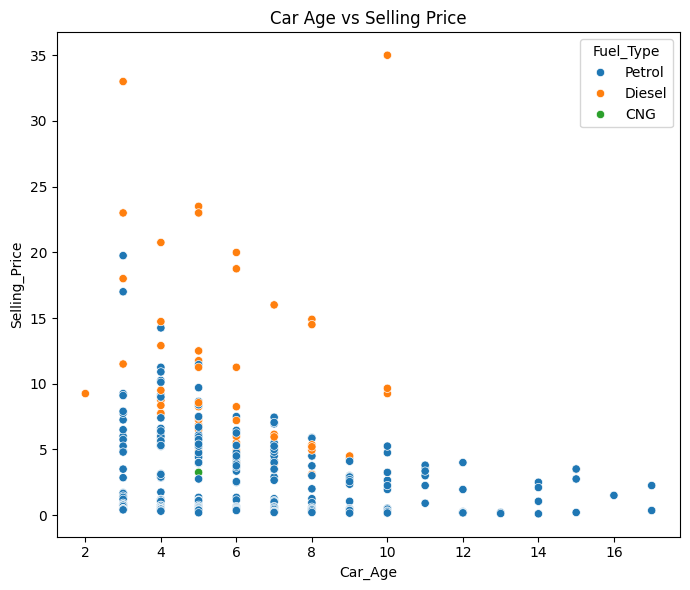

In [ ]:
# Convert registration Year into Car_Age (more meaningful for pricing)
current_year = 2020
df['Car_Age'] = current_year - df['Year']

plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price', hue='Fuel_Type')
plt.title('Car Age vs Selling Price')
plt.tight_layout()
plt.show()

As expected, **Selling Price decreases as Car Age increases** — older cars sell for less, with the steepest drop happening in the first few years.

In [ ]:
# Drop identifier columns not useful for modeling
df_model = df.drop(['Car_Name', 'Year'], axis=1)

# One-hot encode categorical variables
df_model = pd.get_dummies(df_model, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)
df_model.head()

   Selling_Price  Present_Price  Driven_kms  Owner  Car_Age  Fuel_Type_Diesel  Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual
0           3.35           5.59       27000      0        6             False              True                    False                 True
1           4.75           9.54       43000      0        7              True             False                    False                 True
2           7.25           9.85        6900      0        3             False              True                    False                 True
3           2.85           4.15        5200      0        9             False              True                    False                 True
4           4.60           6.87       42450      0        6              True             False                    False                 True


**Feature engineering steps:**\n- `Car_Name` and `Year` dropped — replaced by the more informative `Car_Age`\n- Categorical columns (`Fuel_Type`, `Selling_type`, `Transmission`) converted to numeric via one-hot encoding (`drop_first=True` to avoid redundancy)

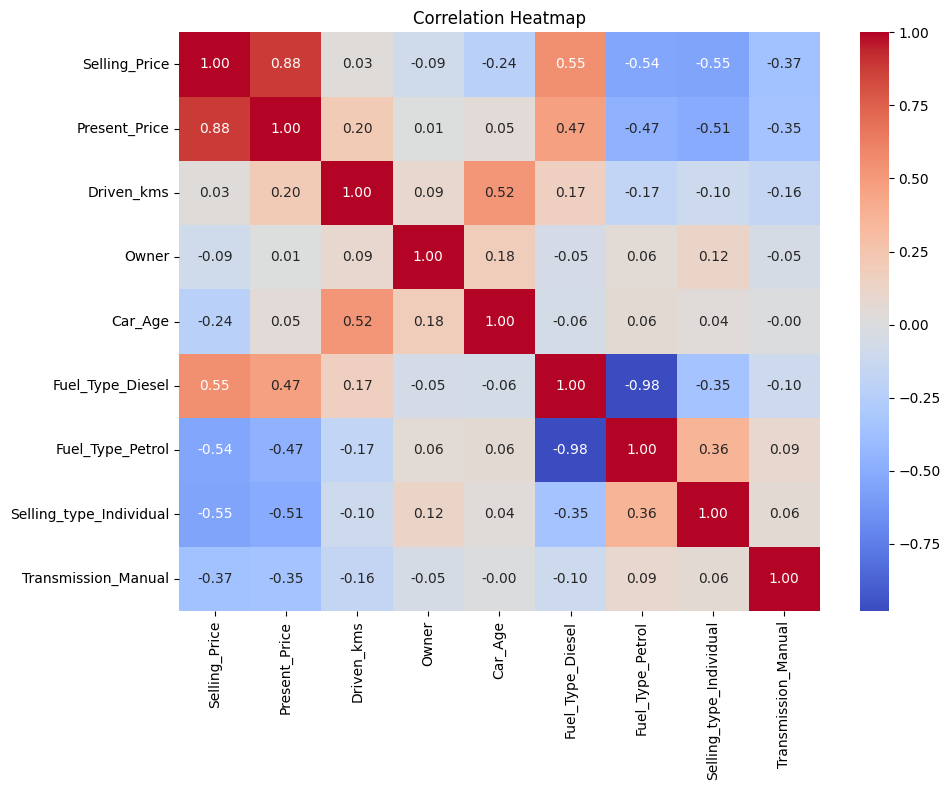

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_model.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

`Present_Price` shows by far the strongest correlation with `Selling_Price` (0.88), confirming it will be the dominant predictor.

## 4. Train/Test Split

In [ ]:
X = df_model.drop('Selling_Price', axis=1)
y = df_model['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (240, 8) | Test: (61, 8)


## 5. Model Training & Evaluation

### 5.1 Linear Regression (baseline)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("R2:  ", r2_score(y_test, lr_pred))
print("MAE: ", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

R2:   0.8488707839193154
MAE:  1.216374019333035
RMSE: 1.8658375680942374


### 5.2 Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("R2:  ", r2_score(y_test, rf_pred))
print("MAE: ", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

R2:   0.9594566919773236
MAE:  0.6368655737704919
RMSE: 0.9664050903676592


**Random Forest clearly outperforms Linear Regression**: R² of **0.96** vs 0.85, and roughly half the error (MAE of ~0.64 lakhs vs 1.22 lakhs). This makes sense — car pricing involves non-linear effects (e.g. depreciation curves) that tree-based models capture better than a straight line.

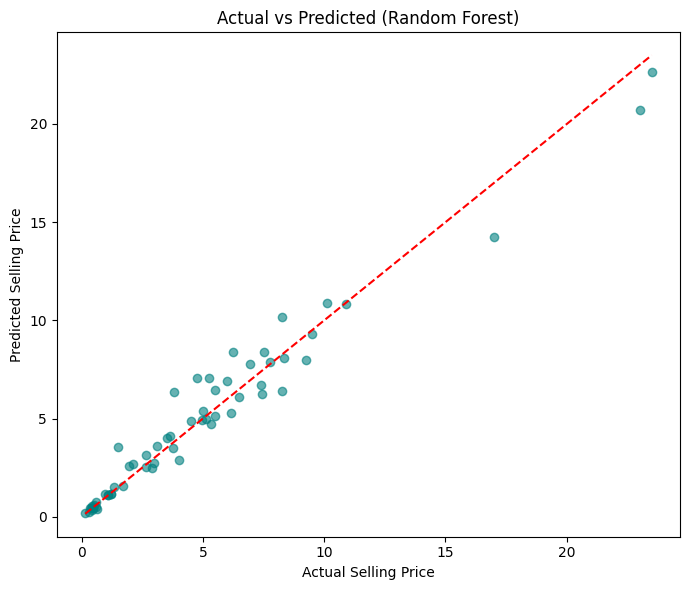

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, rf_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted (Random Forest)')
plt.tight_layout()
plt.show()

Points cluster tightly around the diagonal (perfect-prediction) line, confirming the model's predictions closely track actual prices, with slightly more spread at higher price points.

## 6. Feature Importance

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

Present_Price              0.881166
Car_Age                    0.059495
Driven_kms                 0.040265
Transmission_Manual        0.009646
Fuel_Type_Diesel           0.004339
Fuel_Type_Petrol           0.002564
Selling_type_Individual    0.002155
Owner                      0.000370
dtype: float64


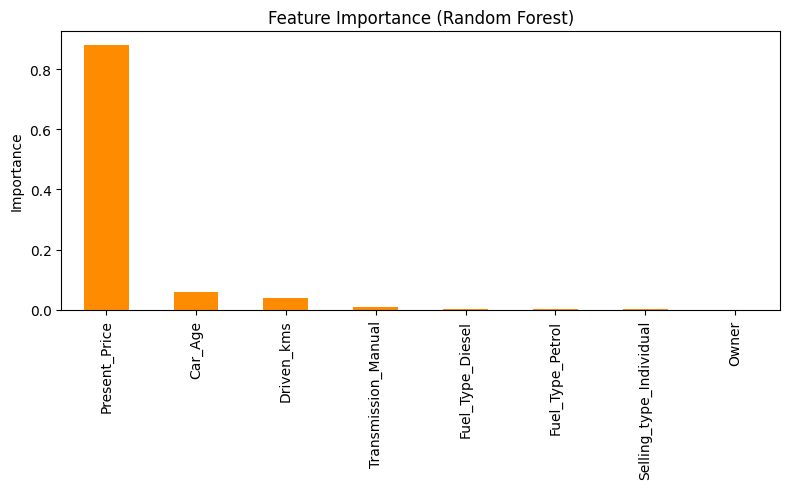

In [ ]:
importances.plot(kind='bar', color='darkorange', figsize=(8,5))
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

**Key takeaways:**
- `Present_Price` (showroom/original price) is overwhelmingly the most important predictor (~88%) — it acts as a strong anchor for resale value.
- `Car_Age` (~6%) and `Driven_kms` / mileage (~4%) are the next most influential — both reflect depreciation and wear.
- Transmission, fuel type, seller type, and ownership history have minor but non-zero effects.

## Real-World Applications of Price Prediction

- **Online marketplaces** (e.g. used-car platforms) can auto-suggest fair listing prices to sellers.
- **Dealerships** can use such models to value trade-ins quickly and consistently.
- **Buyers** can use predicted prices to spot overpriced or underpriced listings.
- The same regression workflow (feature engineering → encoding → train/test split → model comparison → evaluation → feature importance) generalizes to **real estate pricing, insurance premium estimation, and product pricing** in e-commerce.